# 1.5 最简单的选股＋择时＋回测：用 2026 年 A 股真实数据走完一圈

> 面向熟悉 AI 训练、却刚接触股票的读者。你会从真实的沪深 300 成分股中，按估值选池、按 10 日均线决定持仓，再用**下一交易日开盘**模拟成交。这里训练的是研究流程和识别偏差的能力，不是保证赚钱的秘方。

**本节完成什么**：读取并清洗 BaoStock 日行情、东方财富财报 → 每 7 个交易日更新低 PE 股票池 → 每天观察 MA10 上下穿 → 下一交易日开盘交易 → 计算收益、风险、相对基准表现与交易成本。A 股盘口/逐笔因子以及更严谨的事件回测，请继续读主教材 `MiniQuant.ipynb`。

## 先把术语翻译成人话

| 词 | 人话 | 在这里的严格含义 |
|---|---|---|
| 股票池 | 允许考虑买的清单 | 固定 2026-01-05 沪深 300 成分股中，每 7 个交易日按条件选出的最多 100 只 |
| 基本面 | 公司经营情况 | 财报的每股收益 EPS；估值 PE 使用 BaoStock 日字段 |
| PE / 市盈率 | 股价相对盈利贵不贵 | 此处采用 BaoStock 的 `peTTM`，限定 `0<PE<30`；便宜不等于值得买 |
| 日 K 线 | 一天价格摘要 | 开、高、低、收；下单前只能用**已收盘**的日线 |
| MA10 | 最近十个交易日均价 | 各股票近 10 个有记录交易日收盘价的算术平均 |
| 上穿/下穿 | 价格从均线一侧越到另一侧 | 前一日 `收盘≤MA10` 且今日 `收盘>MA10` 为上穿；下穿反之 |
| 回测 | 在历史数据上模拟决策 | 必须写清看到信息的时刻、可交易价格、费用和未成交情况 |
| 基准 | 对照组 | 沪深 300 **价格指数**；它并非含分红的全收益指数 |

**一个交易日的钟表**：昨晚以前的财报已知 → 今天 15:00 收盘才知道今天的 PE 与 MA10 → 今晚生成信号 → 明天开盘尝试成交。把今天收盘算出的信号按今天开盘成交，就是偷看未来。

## 数据来源与可复现边界

- 后复权（hfq，BaoStock `adjustflag=1`）日线、`peTTM`、停牌标记、ST 标记、2026-01-05 沪深 300 成分股与沪深 300 指数：`BaoStock`。日线从 2025-12-01 开始，提前留出 MA10 预热期；研究窗口从 2026-01-05 开始。
- 财报：东方财富数据中心财报接口 `RPT_LICO_FN_CPD`，抓取 2025 三季报、年报及 2026 一季报、半年报，读取公告日、更新日、EPS、净利润和营收。它会有空值、日期歧义、修订和重复，不能直接当作“当时已经知道”。
- 数据截止以**实际最后交易日**为准。此版抓取时为 **2026-09-30**；国庆休市期间并无 10 月行情。重新执行 `python tools/build_simple_snapshot.py --end YYYY-MM-DD` 可刷新。
- `data/private/` 为本地快照，受上游网站使用条款约束，**不随公开仓库再分发**。从官网核实来源和使用范围后，在能连接 BaoStock TCP 10030 与东方财富 HTTPS 的网络中自行生成。公开仓库中的代码、规则和教学文字可复核；未取得授权的原始网页数据不打包发布。

这只是固定的**沪深 300 内选 100**，不是全 A 股选 100；固定初始成分股会造成幸存者/样本选择问题。`adjustflag=1` **后复权 hfq** 价格是收益近似，**不是真实可挂单价格**。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tools.simple_framework_core import (
    load_snapshot, clean_inputs, latest_public_report, select_pool,
    build_decisions, run_backtest, performance_metrics,
)

pd.set_option('display.max_columns', 20)
pd.options.display.float_format = '{:,.4f}'.format

### 读取冻结数据，同时核对哈希

哈希像数据指纹：如果文件被截断或悄悄改写，本实验直接报错。缺文件时按上面的方法生成快照；`requirements.txt` 中 BaoStock 请用 0.9.4 或更新的 0.x 版本。

In [2]:
raw_bars, raw_reports, raw_members, raw_benchmark, manifest = load_snapshot()
print({k: manifest[k] for k in ['latest_bar_date', 'stock_count', 'bar_rows', 'report_rows']})
print('行情示例：')
display(raw_bars.head(3))
print('财报原始字段示例：')
display(raw_reports[['SECURITY_CODE', 'REPORTDATE', 'NOTICE_DATE', 'UPDATE_DATE', 'BASIC_EPS']].head(3))

{'latest_bar_date': '2026-09-30', 'stock_count': 300, 'bar_rows': 61200, 'report_rows': 1200}
行情示例：


,date,code,open,high,low,close,volume,amount,tradestatus,peTTM,isST
0,2025-12-01,sh.600000,145.6371,147.4241,145.1266,147.2965,"68,000,214.0000","779,356,764.1000",1,7.8675,0
1,2025-12-01,sh.600009,83.5401,84.6801,83.2485,84.5476,"14,795,792.0000","468,093,581.3100",1,33.5338,0
2,2025-12-01,sh.600010,17.6683,18.1027,17.5958,18.0303,"630,211,885.0000","1,561,118,731.7200",1,111.2505,0


财报原始字段示例：


,SECURITY_CODE,REPORTDATE,NOTICE_DATE,UPDATE_DATE,BASIC_EPS
0,000858,2025-09-30 00:00:00,2025-10-31 00:00:00,2026-04-30 00:00:00,1.6680
1,300122,2025-09-30 00:00:00,2025-10-30 00:00:00,2026-04-28 00:00:00,-0.5547
2,688981,2025-09-30 00:00:00,2025-11-14 00:00:00,2025-11-14 00:00:00,0.4800


## 第一关：先清洗，再谈策略

真实网页数据会有“数字其实是字符串”、缺值、同一股票同一日期重复、公告日期和更新日期不同、停牌与无成交、PE 为负或空值。清洗规则**先于结果写定**：日期/数值转换；行情按 `(date, code)` 唯一且 OHLC 为正；财报剔除不合法日期及股票码；用 `max(公告日, 更新日)` 作为保守可用日；EPS 必须大于 0。PE 也必须在 `(0,30)`，且选池当天可交易、非 ST、有 MA10。

这里用后来查询到的“更新日”推迟财报可用时刻，能减少修订信息穿越，但**不能证明某个字段的历史版本在当时确实存在**。真正可上线的研究需要带采集时间和修订历史的 point-in-time (PIT) 库。

In [3]:
bars, reports, members, benchmark, audit = clean_inputs(
    raw_bars, raw_reports, raw_members, raw_benchmark
)
display(pd.Series(audit, name='行数/次数').to_frame())
print('行情日期：', bars.date.min().date(), '→', bars.date.max().date())
print('财报可用日示例：')
display(reports[['code6','REPORTDATE','NOTICE_DATE','UPDATE_DATE','available_on','BASIC_EPS']].head())

,行数/次数
bad_price_rows,0
suspended_rows,98
invalid_pe_rows,22802
bad_report_rows,0
missing_eps_rows,0


行情日期： 2025-12-01 → 2026-09-30
财报可用日示例：


,code6,REPORTDATE,NOTICE_DATE,UPDATE_DATE,available_on,BASIC_EPS
0,000858,2025-09-30,2025-10-31,2026-04-30,2026-04-30,1.6680
1,300122,2025-09-30,2025-10-30,2026-04-28,2026-04-28,-0.5547
2,688981,2025-09-30,2025-11-14,2025-11-14,2025-11-14,0.4800
3,688472,2025-09-30,2025-10-31,2025-10-31,2025-10-31,0.2700
4,688396,2025-09-30,2025-10-31,2025-10-31,2025-10-31,0.3963


**看懂被排除的记录**：`invalid_pe_rows` 是“不满足选池条件”的日记录数，通常包含亏损企业的负 PE，并非全是源站错误；`suspended_rows` 是不能按我们的模型成交的日记录数。清洗审计要区分“坏数据”和“合法但不符合策略条件”，不要把所有被筛掉的都叫脏数据。

## 第二关：选股——为什么要把“已公告”写进代码？

每到第 0、7、14……个研究交易日，用当日收盘看到的 PE 排序，选最小的 100 只。仅保留**当天之前**已公告、且 EPS 为正的最新财报；同日公告也不假设在收盘前可见。财报不是直接替代 PE：`peTTM` 来自 BaoStock，东方财富 EPS 用来做基本面可用性和正盈利交叉核对。此处不是财报原始数据的深度财务质量分析。

为什么不把 2026 年半年报用于 2026 年 1 月选股？因为半年报那时还没公布。为什么不是“PE 越低越好”？低 PE 可能来自周期高点、会计口径、风险溢价；必须随后验证收益是否经得起费用和样本外检验。

In [4]:
example_day = pd.Timestamp('2026-01-05')
known = latest_public_report(reports, example_day)
chosen, eligible = select_pool(bars.loc[bars.date.eq(example_day)], reports, example_day)
print(f'{example_day.date()}：已可用且正 EPS 财报 {len(known)} 家；满足所有条件 {eligible} 家；选入 {len(chosen)} 家')
sample = bars.loc[bars.date.eq(example_day) & bars.code.isin(chosen), ['code','peTTM','close','ma']]
display(sample.sort_values('peTTM').head(10))
assert len(chosen) == 100 and sample.peTTM.between(0,30,inclusive='neither').all()

2026-01-05：已可用且正 EPS 财报 281 家；满足所有条件 186 家；选入 100 家


,code,peTTM,close,ma
839,sh.600015,4.0217,32.3224,32.2705
20423,sh.601169,4.5088,27.1994,27.1353
25523,sh.601668,4.7641,12.2271,12.3078
20627,sh.601186,4.9083,11.3655,11.4480
27767,sh.601818,5.1022,6.9999,7.0622
28175,sh.601838,5.1704,23.0364,23.2009
38783,sz.000001,5.1758,"1,390.7197","1,394.2267"
23483,sh.601390,5.3836,7.7229,7.7257
1043,sh.600016,5.5536,108.7430,108.8277
15323,sh.600919,5.6142,16.9540,16.8243


## 第三关：择时——把“上穿才买、下穿才卖”变成状态机

对每只股票每天检查收盘与 MA10 的相对位置：上穿时，若它在当前股票池中，进入“目标持有”；下穿或 7 日调池被剔除时，退出。**刚进股票池但已经在均线上方，并不直接买**；要等待下一次上穿。这是“上穿才买”的字面实现，能够避免把“位于均线上方”误当作“今天上穿”。

当日计算完成只生成**明日**委托。停牌或零成交量阻止成交，未完成的卖单保留持仓并在下一日继续尝试；它不是“卖出信号出现就神奇地卖掉”。

In [5]:
decisions = build_decisions(bars, reports, benchmark, first='2026-01-05', every=7)
display(decisions[['signal_date','execution_date','rebalance','eligible_count','pool_count','active_count']].head(12))
print('更新股票池次数：', int(decisions.rebalance.sum()))
assert (decisions.execution_date > decisions.signal_date).all()
assert decisions.pool_count.le(100).all()
assert all(x.issubset(y) for x,y in zip(decisions.active,decisions.pool))

,signal_date,execution_date,rebalance,eligible_count,pool_count,active_count
0,2026-01-05,2026-01-06,True,186.0000,100,21
1,2026-01-06,2026-01-07,False,NaN,100,48
2,2026-01-07,2026-01-08,False,NaN,100,40
3,2026-01-08,2026-01-09,False,NaN,100,38
4,2026-01-09,2026-01-12,False,NaN,100,37
5,2026-01-12,2026-01-13,False,NaN,100,45
6,2026-01-13,2026-01-14,False,NaN,100,54
7,2026-01-14,2026-01-15,True,180.0000,100,24
8,2026-01-15,2026-01-16,False,NaN,100,16
9,2026-01-16,2026-01-19,False,NaN,100,14


更新股票池次数： 26


## 第四关：成交模拟——价格、份额、成本都要说明

在下一交易日开盘价成交；先卖再买；按目标持仓等权分配。若目标集合改变或每 7 日调池，就重新等权。手续费＋滑点的演示假设为**单边 10 基点（0.1%）**，买卖各收一次；10 基点不是任何券商的真实统一费率。回测用可分割的“复权价格单位”来近似经济收益，因此不模拟 100 股整数倍、A 股交易税费细则、涨跌停封单、排队、冲击、分红到账。后面会解释为什么这阻碍真实 500 元账户照抄。

**容易踩的坑**：模型每次目标持仓变化都等权，可能产生很多小额交易。只看净值、忽略换手与费用，容易把一个交易不可行的策略误认为好策略。

In [6]:
nav, trades = run_backtest(bars, benchmark, decisions, cost_bps=10)
print('模拟成交笔数：', len(trades), '；未成交委托累计次数：', int(nav.blocked.sum()))
display(trades.head(6))
display(nav[['nav','benchmark_nav','holdings','turnover','cost','drawdown']].tail())
assert nav.index.is_monotonic_increasing and nav.nav.gt(0).all()
assert trades.empty or (trades.date > trades.signal_date).all()

模拟成交笔数： 9430 ；未成交委托累计次数： 10


,date,signal_date,code,side,units,adjusted_price,fee
0,2026-01-06,2026-01-05,sh.600030,BUY,330.1870,142.7762,47.1429
1,2026-01-06,2026-01-05,sh.600050,BUY,"6,363.0627",7.4088,47.1429
2,2026-01-06,2026-01-05,sh.600066,BUY,25.5396,"1,845.8757",47.1429
3,2026-01-06,2026-01-05,sh.600741,BUY,52.5647,896.8534,47.1429
4,2026-01-06,2026-01-05,sh.600926,BUY,"1,160.4431",40.6249,47.1429
5,2026-01-06,2026-01-05,sh.600999,BUY,"1,258.9898",37.4450,47.1429


,nav,benchmark_nav,holdings,turnover,cost,drawdown
date,,,,,,
2026-09-23,0.9932,0.9755,31,0.5804,0.0006,-0.1023
2026-09-24,0.9866,0.9653,28,0.5106,0.0005,-0.1083
2026-09-28,0.9744,0.9490,20,1.4037,0.0014,-0.1193
2026-09-29,0.9765,0.9301,29,0.7525,0.0007,-0.1174
2026-09-30,0.9744,0.9346,31,0.6394,0.0006,-0.1193


## 第五关：绩效指标——每个数字回答什么问题？

设每日组合净值为 $V_t$，基准净值为 $B_t$，日收益 $r_t=V_t/V_{t-1}-1$，基准日收益 $b_t=B_t/B_{t-1}-1$。其中 $N$ 是日收益样本数，$D$ 是首尾日期相差的日历天数；两种年化口径都会显示。风险比率默认一年 **252 个交易日**、年无风险收益率 $R_f=0$（仅是演示基线，应在实务中更换同币种、同期限利率）。

| 指标 | 人话 | 本节精确定义与易错点 |
|---|---|---|
| 单笔收益率 | 一买一卖赚多少 | 无费用时 $(P_{sell}-P_{buy})/P_{buy}$；真实订单要扣双边费用、税及分红影响。本回测主报**组合净值**而非挑盈利单 |
| 总收益率 | 整段净资产涨跌 | $V_T/V_0-1$，已计模拟交易费用 |
| 简单年化 | 按时间比例摊到一年 | 交易日口径 $R_{total}\times252/N$；另报日历日口径 $R_{total}\times365/D$；都不是承诺下一年重复发生 |
| 复合年化 | 相同日复利折算一年 | 交易日口径 $(V_T/V_0)^{252/N}-1$，日历日口径 $(V_T/V_0)^{365/D}-1$；短期样本外推尤其不稳定 |
| 最大回撤 | 历史上最深的坑 | $\min_t(V_t/\max_{s\le t}V_s-1)$；必须先有峰值、后有谷值，不能任取全局最高最低 |
| 波动率 | 净值日变化有多晃 | $\operatorname{std}(r_t)\sqrt{252}$ |
| Beta | 与大盘同涨跌的敏感度 | $\operatorname{Cov}(r_t-r_{f,d}, b_t-r_{f,d})/\operatorname{Var}(b_t-r_{f,d})$；可负、可超 1 |
| Alpha | 扣掉市场暴露后的回归截距 | $\alpha_d=\overline{r-r_{f,d}}-\beta\,\overline{b-r_{f,d}}$，显示 $252\alpha_d$；不是神秘的“独立赚钱保证” |
| Sharpe | 每单位总波动换来多少超额无风险收益 | $\overline{r-r_{f,d}}/\operatorname{std}(r-r_{f,d})\sqrt{252}$，分母不是年化收益率 |
| 信息比率 IR | 相对基准跑赢是否稳定 | $\overline{r-b}/\operatorname{std}(r-b)\sqrt{252}$；跟踪误差是主动收益的波动，不是平均超额收益 |
| Calmar | 年化收益 / 最深坑 | 复合年化收益除以最大回撤绝对值；负收益时会是负数 |

常见“IR>0.5 就好”的阈值脱离频率、基准、样本长度、费用和多次试验次数并不可靠。Alpha、Beta 是同一窗口的**统计估计**，有基准选择和置信区间问题；不能写成“总收益=市场收益×Beta+超额收益×Alpha”。

In [7]:
metrics = performance_metrics(nav, annual_rf=0.0)
for name, value in metrics.items():
    if isinstance(value, (float, np.floating)):
        print(f'{name}: {value:.4f}' + ('（比例）' if name not in ['Beta','夏普比率','信息比率','Calmar','累计换手（单边权重之和）'] else ''))
    else:
        print(f'{name}: {value}')

起止: 2026-01-05 → 2026-09-30
交易日收益样本数: 180
总收益率: -0.0256（比例）
简单年化收益率: -0.0358（比例）
复合年化收益率: -0.0356（比例）
日历天数: 268
简单年化收益率（365日）: -0.0348（比例）
复合年化收益率（365日）: -0.0347（比例）
基准总收益率: -0.0654（比例）
年化波动率: 0.1757（比例）
最大回撤: -0.1292（比例）
Beta: 0.1556
Alpha（日回归截距×252）: -0.0086（比例）
夏普比率: -0.1195
信息比率: 0.2580
Calmar: -0.2756
累计换手（单边权重之和）: 111.5099
累计费用/初始本金: 0.1136（比例）
未成交委托次数: 10


### 用两行手算检查最大回撤与收益率

最大回撤是某个时点相对于此前峰值的损失；如果先跌后涨，之后的高点不能倒过来当之前的峰。示例：`100 → 80 → 120` 的最大回撤是 **−20%**，不是 `(120−80)/120=33.3%`。而 `100 → 120 → 80` 才是 **−33.3%**。

In [8]:
toy = pd.Series([100., 80., 120.])
assert np.isclose((toy / toy.cummax() - 1).min(), -0.20)
assert np.isclose(nav.nav.iloc[-1] / nav.nav.iloc[0] - 1, metrics['总收益率'])
print('公式核对通过；示例最大回撤：', (toy / toy.cummax() - 1).min())

公式核对通过；示例最大回撤： -0.19999999999999996


## 图上同时看收益与风险

蓝线是扣除演示费用后的策略净值，橙线是沪深 300 **价格指数**。两者分红处理不一致；把蓝线减橙线直接称为“可兑现 alpha”是不严谨的。灰色区域展示从历史峰值跌下去的幅度。

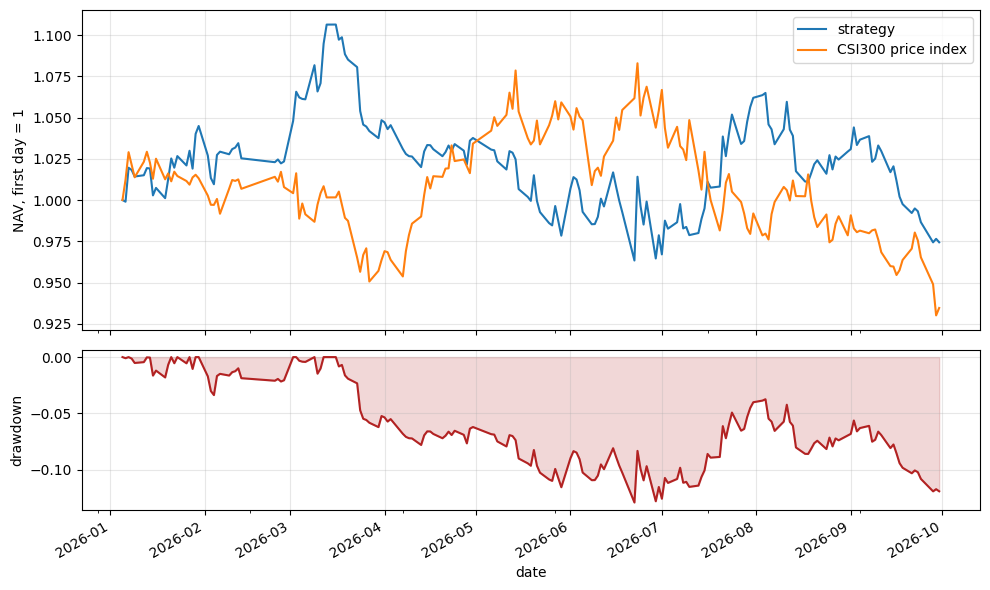

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={'height_ratios':[2,1]})
nav[['nav','benchmark_nav']].rename(columns={'nav':'strategy','benchmark_nav':'CSI300 price index'}).plot(ax=axes[0])
axes[0].set_ylabel('NAV, first day = 1'); axes[0].grid(alpha=.3)
nav.drawdown.plot(ax=axes[1], color='firebrick')
axes[1].fill_between(nav.index, nav.drawdown.to_numpy(), 0, color='firebrick', alpha=.18)
axes[1].set_ylabel('drawdown'); axes[1].grid(alpha=.3)
fig.tight_layout(); plt.show()

## 第六关：交易费敏感性——模型收益对假设有多敏感？

我们在**相同信号与行情**下，只改“单边综合成本”并重新跑回测。这不是挑对自己最有利的成本，而是检查结论是否脆弱。注意模拟订单数量、目标金额也会随费用略变。

In [10]:
cost_scenarios = []
for bps in [0, 5, 10, 20, 30]:
    trial_nav, trial_trades = run_backtest(bars, benchmark, decisions, cost_bps=bps)
    report = performance_metrics(trial_nav)
    cost_scenarios.append({'单边成本_bps': bps, '总收益率': report['总收益率'],
                           '最大回撤': report['最大回撤'], '累计费用/初始本金': report['累计费用/初始本金'],
                           '成交笔数': len(trial_trades)})
display(pd.DataFrame(cost_scenarios).set_index('单边成本_bps'))

,总收益率,最大回撤,累计费用/初始本金,成交笔数
单边成本_bps,,,,
0,0.0894,-0.0910,0.0000,9430
5,0.0303,-0.1103,0.0584,9430
10,-0.0256,-0.1292,0.1136,9430
20,-0.1285,-0.1908,0.2152,9431
30,-0.2207,-0.2566,0.3061,9431


## 回测验收：这次学到什么，而不是编一个漂亮收益

1. **收益**：读总收益、复合年化、最大回撤时，同时读研究时间窗。2026 年截至 9 月末不到一整年，年化只是折算。
2. **容量和可交易性**：股票池 100 只不等于小额账户能每只买 100 股；本例分数份额及复权开盘价只适合方法演示。下一步要换原始可交易价、整手、最低佣金、印花税、涨跌停、成交量约束和真实订单事件。
3. **数据偏差**：固定期初沪深 300 样本、东方财富后来修订的财报、BaoStock 历史 PE、指数价格口径，都需要更好的 PIT 数据和可比的全收益基准。
4. **模型检验**：单一 2026 期间、单一 MA10 与 PE<30 不能证明泛化；继续主教材中的滚动验证、费用、鲁棒性与多重检验。不要根据本页结果反复调阈值，直到曲线好看。
5. **职业作品**：你应能解释每个字段何时知道、为何采用下一开盘、为什么不能用复权价格实盘下单，以及成本和样本选择如何改变结论。能诚实指出策略失败，比伪造高收益更有研究价值。

**延伸练习**：保持测试区间不变，先预测换手上升会如何影响净收益，再运行上面敏感性表验证。随后独立实现“只在第 7 日调池，新增股票若已在均线上方也买入”的替代状态机，并对比其交易频率与风险；必须在查看结果前写下变更理由。

## 轻微改动：让均线慢一点，再看是否真的有 Alpha

前面完全保留用户指定的 **MA10 上穿买、下穿卖** 作为原版。现在只改一个旋钮：均线窗口试 5、10、20、30 日，低 PE 选池、7 日更新、下一开盘、10 基点单边成本均不变。直觉是：较长均线会减少短促波动造成的来回交易；代价是反应更慢。我们只用 **2026-02-02 至 06-30** 比较候选，再展示 **07-01 至 09-30** 的后段。2 月才开始是为了给 MA30 足够的预热数据。

研究者已经看过这份 2026 数据，所以这是**教学性分段检验，不是无人触碰的真正样本外盲测**。我们要同时看 2026 上半年（用于选择）与三季度（用于验证），不能只挑最美的一条全期曲线。Alpha 的定义仍是前述相对沪深 300 日收益的回归截距年化；Alpha>0 是样本内估计，不能承诺未来收益。

In [11]:
def period_metrics(frame):
    part = frame.copy()
    part['nav'] = part.nav / part.nav.iloc[0]
    part['benchmark_nav'] = part.benchmark_nav / part.benchmark_nav.iloc[0]
    part['return'] = part.nav.pct_change()
    part['benchmark_return'] = part.benchmark_nav.pct_change()
    part['drawdown'] = part.nav / part.nav.cummax() - 1
    return performance_metrics(part)

candidates = {}
rows = []
for window in [5, 10, 20, 30]:
    b2, r2, m2, k2, _ = clean_inputs(raw_bars, raw_reports, raw_members, raw_benchmark,
                                      ma_window=window)
    d2 = build_decisions(b2, r2, k2, first='2026-02-02', every=7)
    n2, t2 = run_backtest(b2, k2, d2, cost_bps=10)
    train = period_metrics(n2.loc[:'2026-06-30'])
    test = period_metrics(n2.loc['2026-06-30':])
    whole = performance_metrics(n2)
    candidates[window] = (n2, t2)
    rows.append({'MA日数': window, '上半年Alpha年化': train['Alpha（日回归截距×252）'],
                 '上半年总收益': train['总收益率'], '三季度Alpha年化': test['Alpha（日回归截距×252）'],
                 '三季度总收益': test['总收益率'], '2至9月总收益': whole['总收益率'],
                 '2至9月基准': whole['基准总收益率'],
                 '2至9月费用/本金': whole['累计费用/初始本金'], '成交笔数': len(t2)})
comparison = pd.DataFrame(rows).set_index('MA日数')
display(comparison)
selected_window = int(comparison['上半年Alpha年化'].idxmax())
print('仅按上半年 Alpha 选择的窗口：MA', selected_window, sep='')

,上半年Alpha年化,上半年总收益,三季度Alpha年化,三季度总收益,2至9月总收益,2至9月基准,2至9月费用/本金,成交笔数
MA日数,,,,,,,,
5,-0.2315,-0.0770,0.0202,0.0137,-0.0643,-0.0679,0.1286,9500
10,-0.1508,-0.0467,-0.0179,0.0041,-0.0428,-0.0679,0.0986,8493
20,-0.1688,-0.0536,0.0876,0.0341,-0.0213,-0.0679,0.0745,7537
30,-0.0486,-0.0089,0.1420,0.0469,0.0376,-0.0679,0.0653,7068


仅按上半年 Alpha 选择的窗口：MA30


### 读表时别漏掉失败和限制

如果 MA30 在上半年最优，后段的净收益和 Alpha 也为正，便可以说：**在这份 2026 样本与这些交易假设下**，简单延长均线后跑赢价格指数，并得到正的回归 Alpha。但“上半年最优”仍可能只是四次试验中的偶然胜者；未来年份、其他股票池或真实整手与涨跌停约束可能反转结论。前述原版 MA10 的完整 1—9 月结果仍在上方，不会用改版覆盖掉。

后复权价的关键边界：`adjustflag=1` 是 BaoStock 的 **后复权 hfq**，通常把历史除权分红影响折算到价格序列中；它不是券商 App 中可以填写的每股价格。本例把它当可分割的“收益单位”成交，只能作为**教学性经济收益近似**。实盘级系统须使用当日不复权的报价及真实股数执行，另按除权除息事件更新持仓现金和股数。

## BaoStock 还是 TuShare？为这个实验怎么选

| 问题 | BaoStock | TuShare Pro |
|---|---|---|
| 本例需要的日线、PE、停牌/ST、沪深 300 | 同一个 `query_history_k_data_plus` 和成分接口可直接取；已在本实验实测 | `daily`、`daily_basic`、`index_weight` 等接口可组合，字段与代码需适配 |
| 复权 | `adjustflag=1/2/3` 分别为后复权/前复权/不复权；**本例为 1=hfq** | `pro_bar(adj='hfq'/'qfq')`；文档给出后复权价=未复权价×复权因子 |
| 数据权限 | 本例无账户 Token 即能抓取；但 CodeLab 网络无法直连 BaoStock 的 TCP 端口，所以从可联网机器生成私人快照 | 需 Token，API 按积分/权限与频率分级；`daily_basic`、复权行情等常见接口存在积分门槛 |
| 深入财报研究 | 本例另接东方财富公开网页财报，必须独立清洗公告/修订日期 | 有 `income`、`fina_indicator` 等结构化财务接口及公告日期，更适合扩展财务特征，但权限/历史修订仍需核实 |
| PIT 与实盘成交 | 历史 PE 和复权序列都不能自动证明当时可见，也不提供真实撮合 | `ann_date` 等字段有帮助，但同样不能把“今日下载的历史表”直接当不可修订的 PIT 库 |

**结论**：对零基础且无 TuShare Token 的这个小项目，先用 BaoStock 更容易跑通；如果已有 TuShare 权限、需要成体系的财报字段与涨跌停价等接口，再把数据适配层换成 TuShare。不能笼统说哪家数据“更准”；应按同股票同日期抽样核对交易所公告、复权定义、缺失率和发布时间。本节**没有 TuShare Token，也没有实测两源的误差率**，上表是 API 能力与本次可复现性的对照。

**相关官方文档**：[BaoStock 复权因子说明](https://www.baostock.com/helpdocs/pdf/BaoStock%E5%A4%8D%E6%9D%83%E5%9B%A0%E5%AD%90%E7%AE%80%E4%BB%8B.pdf)、[TuShare A 股复权行情](https://tushare.pro/document/2?doc_id=146)、[TuShare 权限说明](https://tushare.pro/document/1?doc_id=108)、[TuShare A 股日线](https://tushare.pro/document/1?doc_id=27)、[TuShare 财务指标](https://tushare.pro/document/2?doc_id=79)。

## 来源

- [Datawhale whale-quant 第 3 章：股票数据获取](https://datawhalechina.github.io/whale-quant/#/./ch03_%E8%82%A1%E7%A5%A8%E6%95%B0%E6%8D%AE%E8%8E%B7%E5%8F%96/ch03_%E8%82%A1%E7%A5%A8%E6%95%B0%E6%8D%AE%E8%8E%B7%E5%8F%96)：BaoStock API 与常见指标入门。本节代码与说明重新编写。
- [东方财富首页](https://www.eastmoney.com/default.html)、[东方财富数据中心](https://data.eastmoney.com/bbsj/)：上市公司报告数据入口；最终以公告原文与交易所披露为准。
- [上海证券交易所 2026 年休市安排](https://www.sse.com.cn/disclosure/dealinstruc/closed/)：解释 2026-10-01 至 10-07 无交易数据。
- [东方财富法律声明](https://about.eastmoney.com/home/disclaimer)、[服务协议](https://about.eastmoney.com/home/protocol)：使用或分发数据前核验许可。